In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D
import warnings; warnings.simplefilter('ignore')
import sys
import h5py
import pandas as pd
import seaborn as sns
sys.path.insert(0, '/Users/jsmonzon/Research/SatGen/mcmc/src/')
import jsm_ancillary
import jsm_visualize
import jsm_SHMR
import jsm_mcmc
import jsm_stats
import jsm_models
import evolve as ev
import galhalo as gh
import profiles as profiles
import config as cfg

In [3]:
plt.style.use('../../../SatGen/notebooks/paper1/paper.mplstyle')
double_textwidth = 7.0 #inches
single_textwidth = 3.5 #inches
levelz = [1-0.99, 1-0.95, 1-0.68]

In [4]:
zzli = jsm_ancillary.load_sample("../../data/orbit_runs/13.0_files.h5")
zentner = jsm_ancillary.load_sample("../../data/orbit_runs/zentner.h5")
zentner_v2 = jsm_ancillary.load_sample("../../data/orbit_runs/zentner_v2.h5")
jiang = jsm_ancillary.load_sample("../../data/orbit_runs/jiang.h5")
identical_v2 = jsm_ancillary.load_sample("../../data/orbit_runs/identical_v2.h5")
identical = jsm_ancillary.load_sample("../../data/orbit_runs/identical.h5")

In [5]:
jsm_stats.correlation(np.log10(1+zzli["host_concentration"].values), zzli["N_artcut"].values)

-0.27040248982596227

In [6]:
jsm_stats.correlation(np.log10(1+jiang["host_concentration"].values), jiang["N_artcut"].values)

-0.2835022777272164

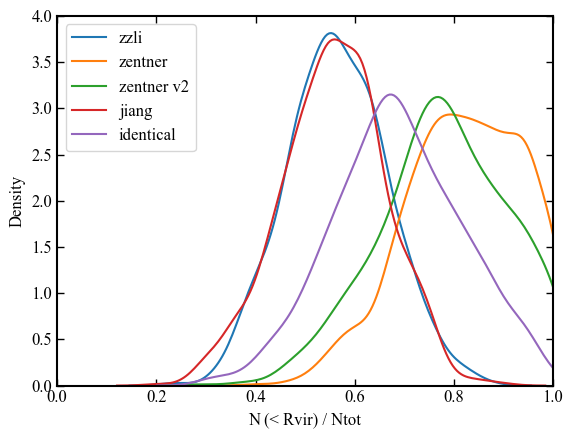

In [7]:
sns.kdeplot(zzli["N_Rvircut"]/zzli["N_cut"], label="zzli")
sns.kdeplot(zentner["N_Rvircut"]/zentner["N_cut"], label="zentner")
sns.kdeplot(zentner_v2["N_Rvircut"]/zentner_v2["N_cut"], label="zentner v2")
sns.kdeplot(jiang["N_Rvircut"]/jiang["N_cut"], label="jiang")
sns.kdeplot(identical["N_Rvircut"]/identical["N_cut"], label="identical")
# sns.kdeplot(identical_v2["N_Rvircut"]/identical_v2["N_cut"], label="identical_v2")

plt.xlim(0, 1)
plt.ylim(0, 4)

plt.xlabel("N (< Rvir) / Ntot")
plt.legend()
plt.show()

In [8]:
def plot_z50_vs_N(database):
    # Compute quantities
    x = np.log10(1 / (1 + database['host_z50']))
    y = np.log10(database['N_artcut'])

    # Correlation (use original variables, as you did)
    rho = jsm_stats.correlation(x-np.median(x),
                                y-np.median(y))

    # Plot
    fig, ax = plt.subplots()

    ax.scatter(x-np.median(x), y-np.median(y), marker=".", alpha=0.5)
    sns.kdeplot(x=x-np.median(x), y=y-np.median(y), levels=levelz, ax=ax)

    ax.set_title(f"$\\rho_S$ = {rho:.3f}")
    ax.set_ylabel(r"$\Delta \, \log N_{\rm sub}$")
    ax.set_xlabel(r"$\Delta \, \log \, a_{1/2}$")

    # ax.axhline(0, ls="--", color="k")
    # ax.axvline(0, ls="--", color="k")
    # ax.set_ylim(-0.6, 0.6)
    # ax.set_xlim(-0.35, 0.35)

    plt.show()

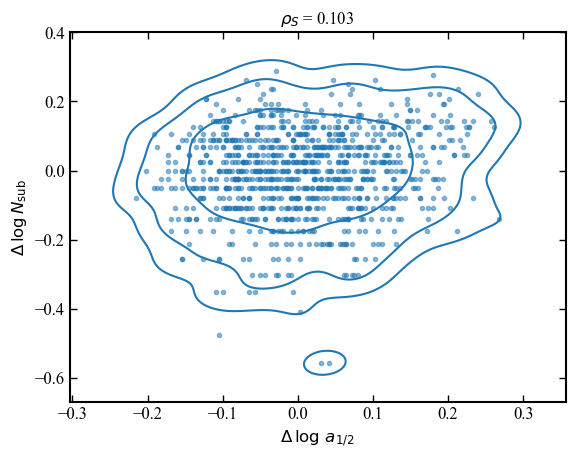

In [9]:
plot_z50_vs_N(zzli)

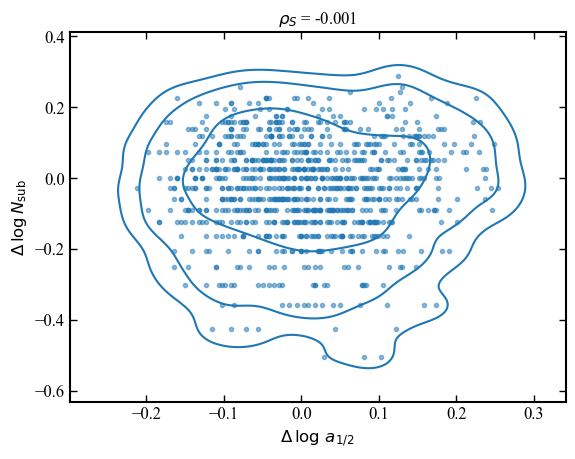

In [10]:
plot_z50_vs_N(jiang)

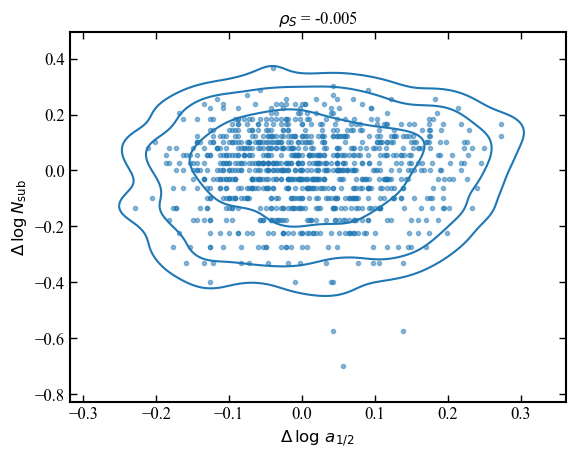

In [11]:
plot_z50_vs_N(zentner)

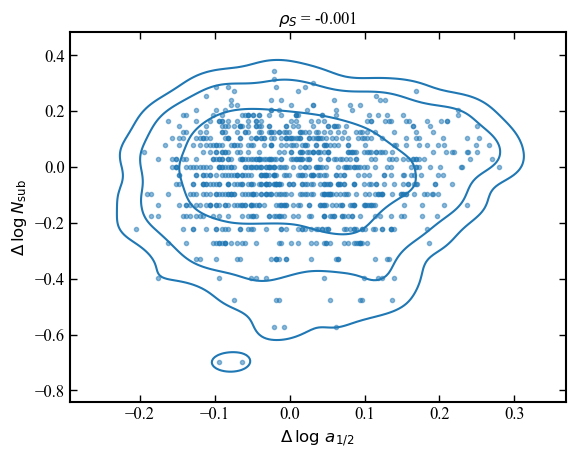

In [12]:
plot_z50_vs_N(zentner_v2)

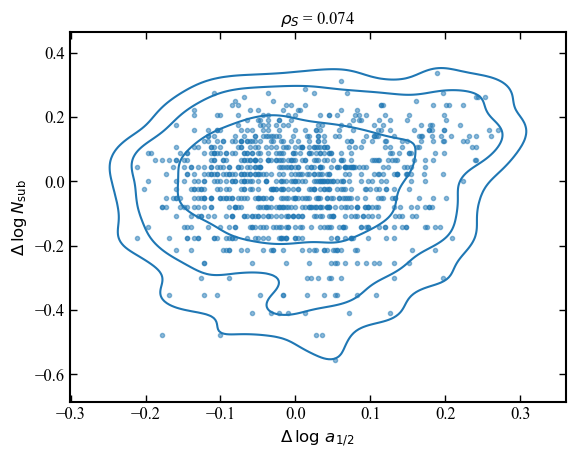

In [13]:
plot_z50_vs_N(identical)

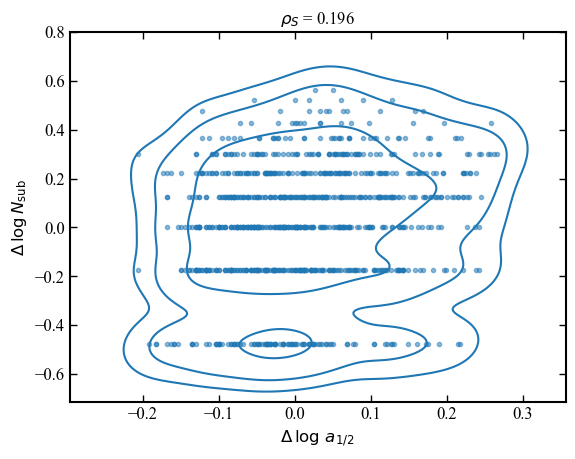

In [14]:
plot_z50_vs_N(identical_v2)

In [ ]:
identical = jsm_visualize.Tree_Vis(file="../../data/orbit_runs/trees/tree_evo_identical.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)
identical.make_orbit_movie(video_path="../../data/orbit_runs/trees/identical.mp4", scale=800)

In [8]:
identical_v2 = jsm_visualize.Tree_Vis(file="../../data/orbit_runs/trees/tree_evo_identical_v2.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)
identical_v2.make_orbit_movie(video_path="../../data/orbit_runs/trees/identical_v2.mp4", scale=800)

plotting all subhalos!


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [9]:
jiang = jsm_visualize.Tree_Vis(file="../../data/orbit_runs/trees/tree_evo_jiang.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)
jiang.make_orbit_movie(video_path="../../data/orbit_runs/trees/jiang.mp4", scale=800)

plotting all subhalos!


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [10]:
zzli = jsm_visualize.Tree_Vis(file="../../data/orbit_runs/trees/tree_evo_zzli.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)
zzli.make_orbit_movie(video_path="../../data/orbit_runs/trees/zzli.mp4", scale=800)

plotting all subhalos!


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [11]:
zentner = jsm_visualize.Tree_Vis(file="../../data/orbit_runs/trees/tree_evo_zentner.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)
zentner.make_orbit_movie(video_path="../../data/orbit_runs/trees/zentner.mp4", scale=800)

plotting all subhalos!


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [12]:
zentner_v2 = jsm_visualize.Tree_Vis(file="../../data/orbit_runs/trees/tree_evo_zentner_v2.npz", merger_crit=-2, fesc=0.2, scatter=False, verbose=False)
zentner_v2.make_orbit_movie(video_path="../../data/orbit_runs/trees/zentner_v2.mp4", scale=800)

plotting all subhalos!


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 600) to (800, 608) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).
